# Case 6: Minimize standard deviation and force some assets subsets to an specific weight within the portfolio

## Data load

In [225]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import (
    sparsemax,
)

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")

### Index and components

In [226]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [227]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"
train_start_date = "2019-12-31"
train_end_date = "2020-12-31"
test_start_date = "2021-01-01"
test_end_date = "2021-06-30"

# Sync dataframes
data, data_idx = dm.DataManagement.sync_dataframes(data, data_idx)
data_log_ret = dm.DataManagement.convert_prices_to_log_returns(data)

# Compute logarithmic returns.
data_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(data_idx)

# Filter dates.
data_log_ret = data_log_ret.loc[ds_start_date:ds_end_date, :]
data_idx_log_ret = data_idx_log_ret.loc[ds_start_date:ds_end_date, :]

# Train and test datasets.
X_train, y_train, X_test, y_test = dm.DataManagement.train_test_split_by_date(
    X=data_log_ret,
    y=data_idx_log_ret,
    train_start_date=train_start_date,
    train_end_date=train_end_date,
    test_start_date=test_start_date,
    test_end_date=test_end_date,
    train_freq="D",
)

In [228]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using gradient descent

* We create `num_masks` masks.
* For each mask, we randomly select `num_assets_in_mask` assets without replacement and set their position in the mask to `1`.
* We assign a random weight to each mask and ensure it sums to 1 in `assets_mask_weights`.

In [ ]:
rng = np.random.default_rng(42)

num_masks = 4
num_assets = X_train.shape[1]
assets_mask = np.zeros(shape=(num_assets, num_masks))
num_assets_in_mask = 10
num_assets_in_portfolio = num_assets_in_mask * num_masks  # We will select X assets in each mask.

asset_indexes = rng.choice(range(num_assets), size=num_assets_in_portfolio, replace=False)
print(f"Selected asset indexes: {X_train.columns[asset_indexes]}")

for m in range(num_masks):
    for ai in asset_indexes[m * num_assets_in_mask : (m + 1) * num_assets_in_mask]:
        # print(m, ai)
        assets_mask[ai, m] = 1

assets_mask_weights = rng.integers(low=1, high=100, size=num_masks)
assets_mask_weights = assets_mask_weights / np.sum(assets_mask_weights)  # Normalize.
print(f"Normalized mask weights: {assets_mask_weights} | Total: {np.sum(assets_mask_weights)}")
assets_mask_weights -= 0.10 / num_masks  # Subtract X% so it doesn't sum to 100%.
print(f"Normalized mask weights with -10%: {assets_mask_weights} | Total: {np.sum(assets_mask_weights)}")

Selected asset indexes: Index(['RVTY', 'AVY', 'TJX', 'CL', 'AMZN', 'TSCO', 'UDR', 'AWK', 'HIG', 'MTB',
       'KMB', 'ATO', 'HAL', 'MO', 'GE', 'BK', 'CPRT', 'MRK', 'INTC', 'RTX',
       'NSC', 'IPG', 'GILD', 'SYY', 'OXY', 'SO', 'O', 'IT', 'ROP', 'CHD',
       'PPG', 'EXPE', 'DLR', 'PNC', 'LH', 'MDLZ', 'PCG', 'FSLR', 'HBAN',
       'ARE'],
      dtype='object')
Pesos normalizados de las máscaras: [0.30316742 0.42533937 0.19909502 0.07239819] | Total: 0.9999999999999999
Pesos normalizados de las máscaras con -10%: [0.27816742 0.40033937 0.17409502 0.04739819] | Total: 0.8999999999999999


In [ ]:
def custom_loss_function(
    l_std=0.0,
    l_asset_subset=0.0,
    asset_subset_mask=None,
    asset_subset_weights=None,
):
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # We want the lambdas to be positive.
        lambda_std = tf.nn.relu(l_std)
        lambda_asset_subset = tf.nn.relu(l_asset_subset)

        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # Risk as standard deviation.
        ###############
        std = rm.RiskMeasures.Std_tf(x=p_rets)
        penalty_std = std

        ####################
        # Operations with the mask and constraints.
        ####################

        # Masked weights by subset.
        w_masked = tf.multiply(w, asset_subset_mask)

        # Sum of weights by subset.
        sum_w_masked = tf.reduce_sum(w_masked, axis=0)
        # penalty_masked = tf.reduce_sum(tf.sqrt(tf.square(sum_w_masked - asset_subset_weights)))
        penalty_masked = tf.reduce_sum(tf.abs(asset_subset_weights - sum_w_masked))

        # Update the loss.
        loss = lambda_std * penalty_std + lambda_asset_subset * penalty_masked

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "loss_std": (lambda_std * penalty_std).numpy(),
                "loss_asset_subset": (lambda_asset_subset * penalty_masked).numpy(),
            },
        }

    return loss_function

In [ ]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [ ]:
def custom_weights_function():
    return sparsemax

In [ ]:
num_assets = X_train.shape[1]
loss_function = custom_loss_function(
    l_std=1.0 / 0.01,
    l_asset_subset=1.0 / 0.1,
    asset_subset_mask=tf.convert_to_tensor(assets_mask, dtype=tf.float32),
    asset_subset_weights=tf.convert_to_tensor(assets_mask_weights, dtype=tf.float32),
)
weights_function = custom_weights_function()
get_best_weights_function = custom_get_best_weights()

# Define the optimizer with the learning rate.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0009)

mpo = MPOModel(
    num_assets=num_assets,
    loss_function=loss_function,
    weights_function=weights_function,
    get_best_weights_function=get_best_weights_function,
    optimizer=optimizer,
    random_weight_init=False,
)

In [234]:
history = mpo.fit(x=X_train, idx=y_train, epochs=8000)

100%|██████████| 8000/8000 [00:46<00:00, 172.02it/s]


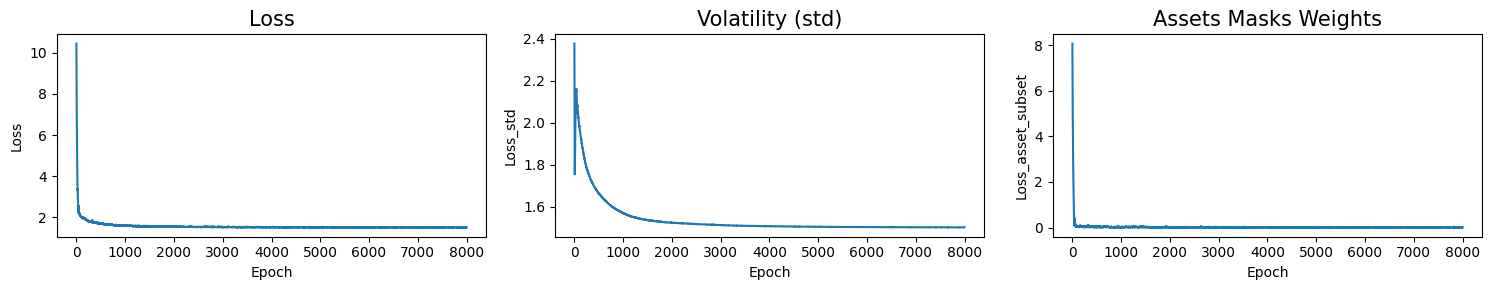

In [235]:
mpo.plot_all_training_metrics(
    save_as="../results/Case_06/MinStd_AssetSubsetWeight_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "loss_std": "Volatility (std)",
        "loss_asset_subset": "Assets Masks Weights",
    },
)

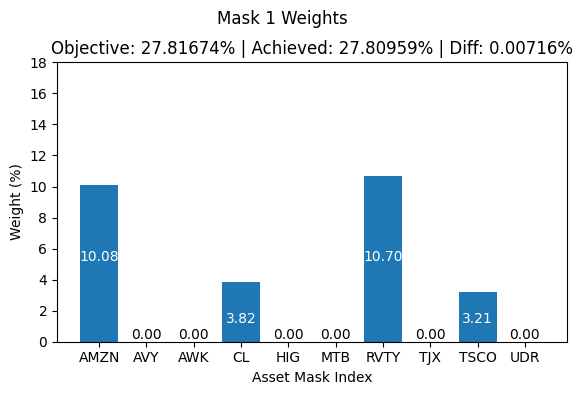

Objective: 0.2781674208144796 | Achieved: 0.27809585571289064 | Diff: 7.156510158895513e-05


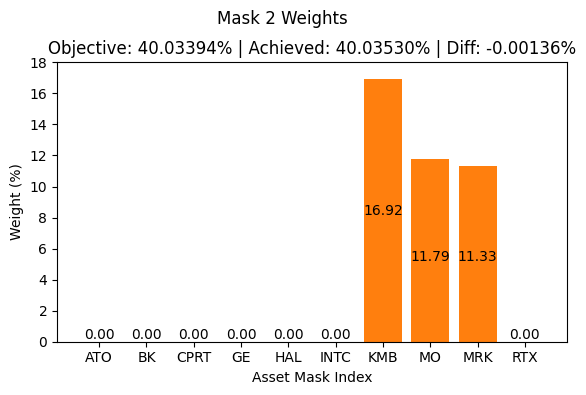

Objective: 0.40033936651583707 | Achieved: 0.40035301208496094 | Diff: -1.364556912386572e-05


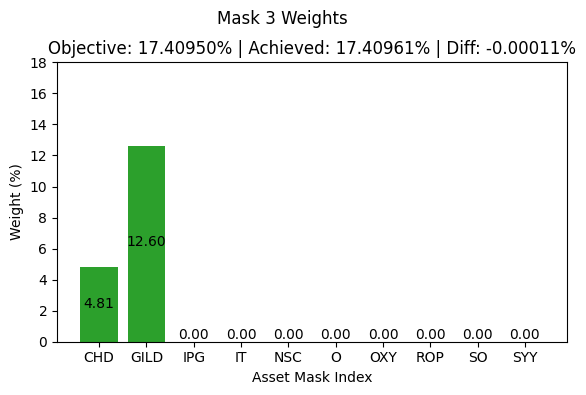

Objective: 0.17409502262443438 | Achieved: 0.17409610748291016 | Diff: -1.0848584757749968e-06


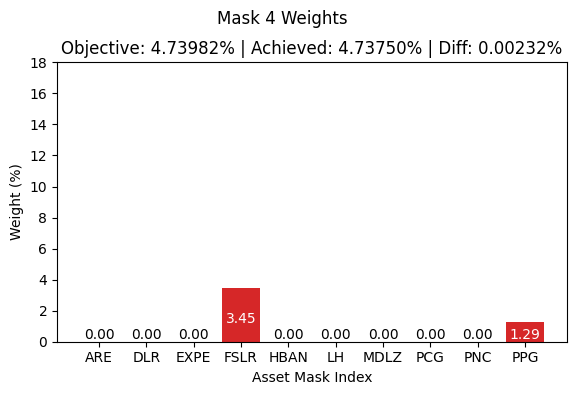

Objective: 0.047398190045248874 | Achieved: 0.04737496376037598 | Diff: 2.3226284872897296e-05


In [ ]:
import matplotlib.pyplot as plt

df = pd.DataFrame(mpo.get_best_weights(), index=X_train.columns, columns=["Weight"])

masks_color = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fonts_color = ["#ffffff", "#000000", "#000000", "#ffffff"]
bars_color = []
bars_weight = []
bars_label = []

for m in range(num_masks):
    am = assets_mask[:, m]
    objective_weight = assets_mask_weights[m]

    df[f"Mask {m + 1}"] = am
    selection_mask = df[f"Mask {m + 1}"] == 1
    labels = df.loc[selection_mask].index
    weights = df.loc[selection_mask, "Weight"] * 100

    plt.figure(figsize=(6, 3))
    plt.bar(labels, weights, color=masks_color[m])
    for x, y in enumerate(weights):
        if y == 0.0:
            plt.text(x, y, f"{y:.2f}", ha="center", va="bottom")
        else:
            plt.text(
                x,
                y // 2,
                f"{y:.2f}",
                ha="center",
                va="bottom",
                fontdict={"color": fonts_color[m]},
            )
    plt.ylim(0, 18)

    bars_color.extend([masks_color[m]] * len(weights))
    bars_weight.extend(weights)
    bars_label.extend(list(X_train.columns[asset_indexes[m * num_assets_in_mask : (m + 1) * num_assets_in_mask]]))

    plt.xlabel("Asset Mask Index")
    plt.ylabel("Weight (%)")
    plt.suptitle(f"Mask {m + 1} Weights", y=1.3, fontsize=12)
    plt.title(
        f"Objective: {objective_weight:.5%} | Achieved: {weights.sum() / 100:.5%} | Diff: {objective_weight - weights.sum() / 100:.5%}"
    )
    plt.tight_layout(rect=[0, 0, 1, 1.36])
    plt.savefig(
        f"../results/Case_06/MinStd_AssetSubsetWeight_gd_optimizer_mask_{m + 1}_weights.png",
        bbox_inches="tight",
    )
    plt.show()
    print(
        f"Objective: {objective_weight} | Achieved: {weights.sum() / 100} | Diff: {objective_weight - (weights.sum() / 100)}"
    )

In [237]:
df

,Weight,Mask 1,Mask 2,Mask 3,Mask 4
A,0.0,0.0,0.0,0.0,0.0
AAPL,0.0,0.0,0.0,0.0,0.0
ABT,0.0,0.0,0.0,0.0,0.0
ACGL,0.0,0.0,0.0,0.0,0.0
ACN,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
XEL,0.0,0.0,0.0,0.0,0.0
XOM,0.0,0.0,0.0,0.0,0.0
YUM,0.0,0.0,0.0,0.0,0.0
ZBH,0.0,0.0,0.0,0.0,0.0


In [238]:
df = pd.DataFrame(mpo.get_best_weights(), index=X_train.columns, columns=["Weight"])
df.loc[:, "Color"] = "#7f7f7f"
df.loc[bars_label, "Color"] = bars_color
mask = df["Weight"] > 0.0
df = df[mask]
df

,Weight,Color
AMZN,0.100774,#1f77b4
CHD,0.048100,#2ca02c
CL,0.038216,#1f77b4
DPZ,0.026160,#7f7f7f
FSLR,0.034484,#d62728
GILD,0.125996,#2ca02c
KMB,0.169192,#ff7f0e
KR,0.073919,#7f7f7f
MO,0.117910,#ff7f0e
MRK,0.113251,#ff7f0e


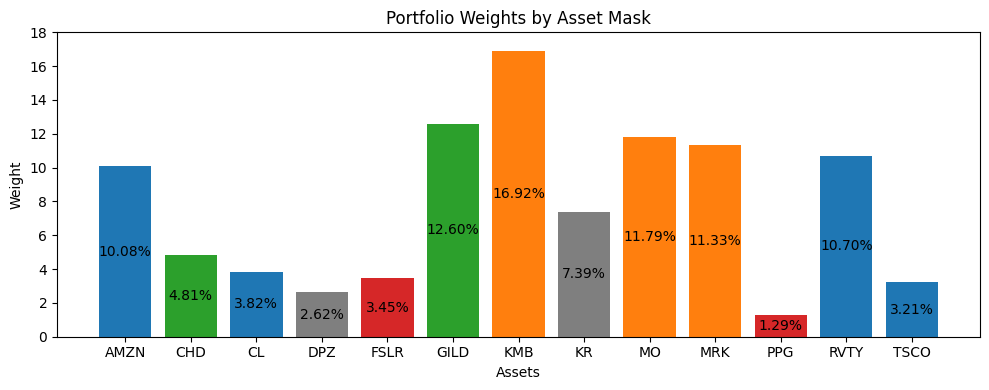

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Create the figure and bar chart
plt.figure(figsize=(10, 4))
bars = plt.bar(x=df.index, height=df["Weight"] * 100, color=df["Color"])

# Add the value of each weight in the middle of the bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{height:.2f}%", ha="center", va="center")

# Labels and title
plt.ylim(0, 18)
plt.xlabel("Assets")
plt.ylabel("Weight")
plt.title("Portfolio Weights by Asset Mask")

plt.tight_layout()
plt.savefig(
    f"../results/Case_06/MinStd_AssetSubsetWeight_gd_optimizer_portfolio_colored_weights_no_zeros.png",
    bbox_inches="tight",
)
plt.show()

In [240]:
gd_portfolio_name = "Case 6 - GD"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=X_train.columns,
)

Number of assets in portfolio: 13


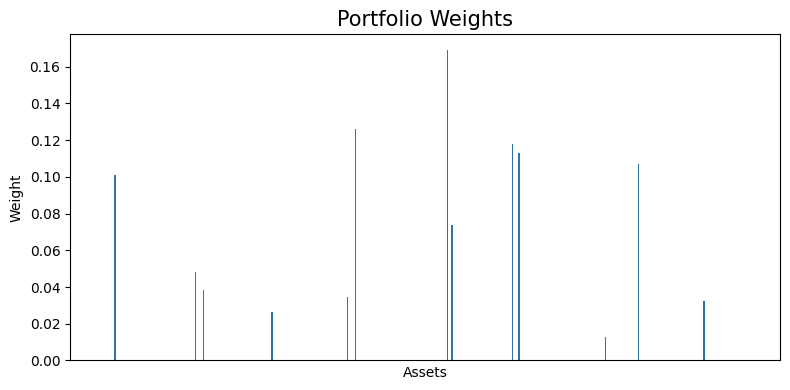

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [241]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    save_as="../results/Case_06/MinStd_AssetSubsetWeight_gd_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 13


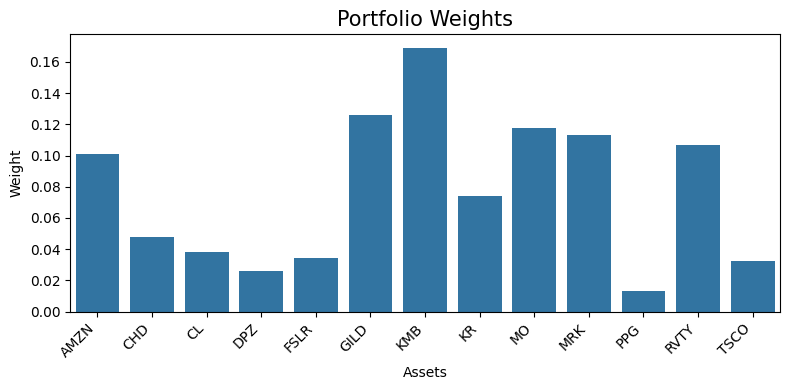

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & AMZN & CHD & CL & DPZ & FSLR & GILD & KMB & KR & MO & MRK & PPG & RVTY & TSCO \\
\midrule
Weight & 0.100774 & 0.048100 & 0.038216 & 0.026160 & 0.034484 & 0.125996 & 0.169192 & 0.073919 & 0.117910 & 0.113251 & 0.012891 & 0.106993 & 0.032112 \\
\bottomrule
\end{tabular}



In [242]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    save_as="../results/Case_06/MinStd_AssetSubsetWeight_gd_optimizer_portfolio_weights_no_zeros.png",
)

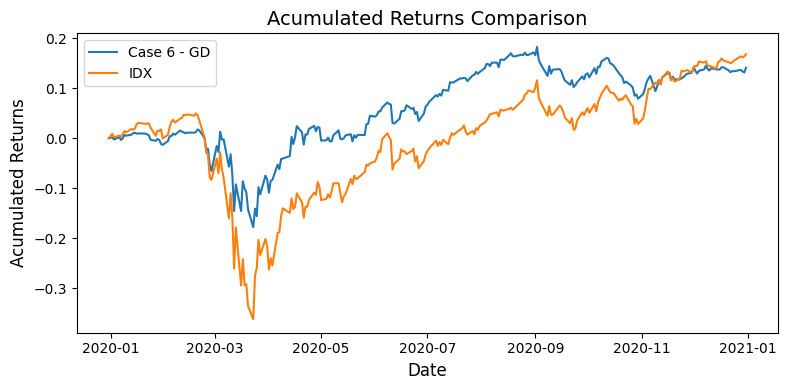

                  Std    Sharpe  TrackingError       VaR      CVaR  \
Case 6 - GD  0.015007  0.016130       0.010666  0.024383  0.038194   
IDX          0.021113  0.016771       0.000000  0.033728  0.056878   

             WeightsOver10pct  WeightsOver5pct  
Case 6 - GD          0.134116         0.808035  
IDX                       NaN              NaN  


In [ ]:
# Nos permite almacenar y comparar las distintas carteras.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=X_train.columns)

portfolios.replace_or_add_portfolio(
    name=gd_portfolio.name,
    new_portfolio=gd_portfolio,
)

portfolios.plot_cumulative_returns(
    asset_returns=X_train,
    idx_returns=y_train,
    nombres_carteras=[
        gd_portfolio.name,
    ],
    plot_idx=True,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_06/MinStd_AssetSubsetWeight_gd_optimizer_portfolio_acum_returns.png",
)